# Exp7.3.7 — Whole-count Linear bias transfer to LIF count space

Analysis-only notebook. It reads finalized artifacts and shows aggregate method-level comparisons across the three seeds; it does not train models or launch jobs.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('artifacts/experiment_7_3_7_wholecount_bias_transfer/wholecount_bias_transfer_v1')
if not ROOT.exists():
    ROOT = Path('notebooks') / ROOT

methods = pd.read_csv(ROOT / 'method_summary.csv')
gaps = pd.read_csv(ROOT / 'gap_summary.csv')
bias = pd.read_csv(ROOT / 'bias_vector_summary.csv')
history = pd.read_csv(ROOT / 'calibration_history_summary.csv')
source_checks = json.loads((ROOT / 'source_reproduction_checks.json').read_text())
manifest = json.loads((ROOT / 'manifest.json').read_text())

print('Experiment:', manifest['experiment_id'])
print('Source reproduction:', source_checks)


Experiment: experiment_7_3_7_wholecount_bias_transfer
Source reproduction: {'available': True, 'max_abs_delta_pp': 0.0, 'paired_test_ba_delta_pp': {'L0_linear_no_bias': [0.0, 0.0, 0.0], 'L1_linear_affine': [0.0, 0.0, 0.0]}, 'source': 'notebooks/artifacts/experiment_7_3_2_affine_probe_bridge/affine_probe_bridge_v1/method_runs.csv'}


## Final method comparison

`L1` is the affine whole-count Linear reference. `L2` transfers exactly the same raw Linear weight matrix to the beta=0.5 output LIF with no LIF weight training. `L3/L4` only add continuous/integer output-count offsets.


In [2]:
cols = [
    'method', 'train_ba_mean', 'val_ba_mean', 'test_ba_mean', 'test_ba_std',
    'weight_l2_mean', 'bias_l2_mean', 'bias_span_mean'
]
methods[cols]


,method,train_ba_mean,val_ba_mean,test_ba_mean,test_ba_std,weight_l2_mean,bias_l2_mean,bias_span_mean
0,L0_linear_no_bias,0.971001,0.559666,0.540981,0.036907,0.50814,0.000000,0.000000
1,L1_linear_affine,0.914686,0.561795,0.586273,0.009744,0.07918,4.848924,3.958947
2,L2_same_w_lif_count,0.083333,0.083333,0.083333,0.000000,0.07918,0.000000,0.000000
3,L3_same_w_lif_continuous_bias,0.083333,0.083333,0.083333,0.000000,0.07918,1.986865,2.099511
4,L4_same_w_lif_integer_bias,0.083333,0.083333,0.083333,0.000000,0.07918,0.000000,2.000000


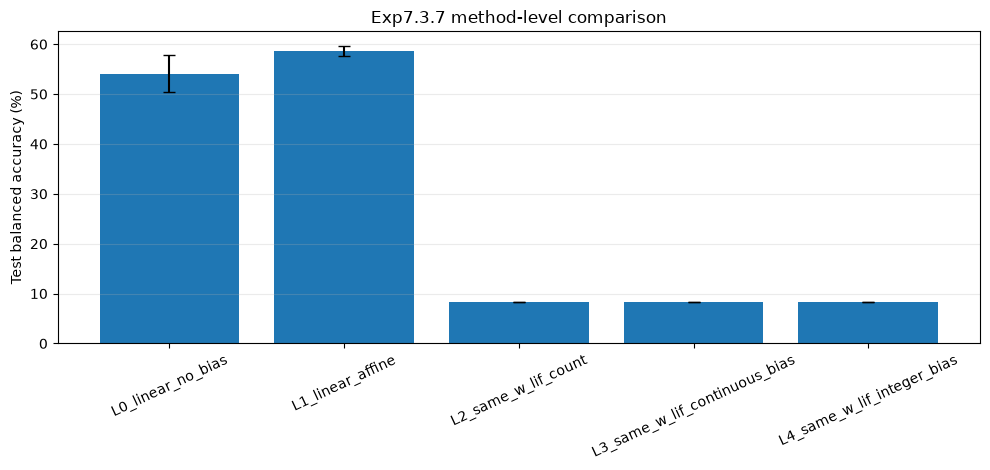

In [3]:
plot_df = methods.set_index('method').loc[manifest['methods']].reset_index()
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(plot_df['method'], 100 * plot_df['test_ba_mean'], yerr=100 * plot_df['test_ba_std'], capsize=4)
ax.set_ylabel('Test balanced accuracy (%)')
ax.set_title('Exp7.3.7 method-level comparison')
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


## Where the performance moves

These paired contrasts decompose the benefit of the Linear affine bias, the same-W Linear-to-LIF realization loss, and how much is recovered by fixed output-count bias.


In [4]:
gaps


,contrast,delta_pp_mean,delta_pp_std,count
0,linear_bias_gain_pp,4.529198,3.331324,3.0
1,linear_to_lif_loss_pp,50.294012,0.974413,3.0
2,continuous_bias_recovery_pp,0.000000,0.000000,3.0
3,integer_bias_recovery_pp,0.000000,0.000000,3.0
4,integer_vs_continuous_pp,0.000000,0.000000,3.0
5,remaining_gap_after_continuous_pp,50.294012,0.974413,3.0
6,remaining_gap_after_integer_pp,50.294012,0.974413,3.0


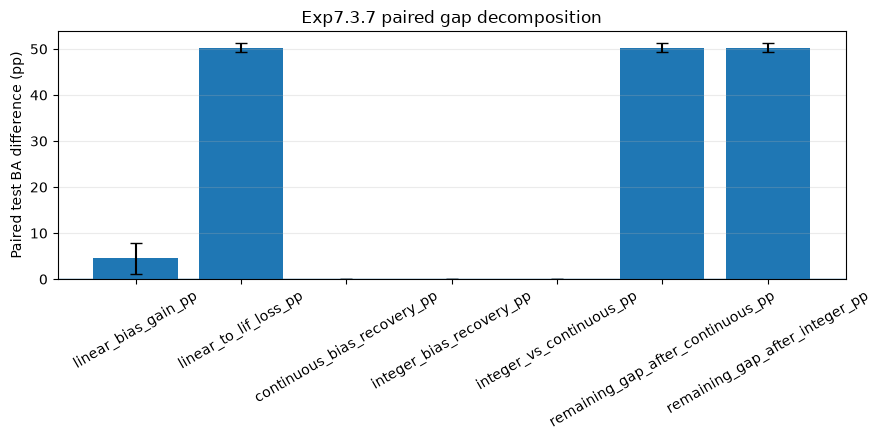

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(gaps['contrast'], gaps['delta_pp_mean'], yerr=gaps['delta_pp_std'], capsize=4)
ax.axhline(0, linewidth=1)
ax.set_ylabel('Paired test BA difference (pp)')
ax.set_title('Exp7.3.7 paired gap decomposition')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


## Learned class-specific count offsets

The continuous count-space bias is gauge-fixed to zero mean for training. For integer virtual spikes, each seed is shifted so the minimum class offset is zero before rounding.


In [6]:
bias


,class_index,linear_bias_logit_mean,linear_bias_logit_std,linear_bias_logit_count,lif_count_bias_centered_mean,lif_count_bias_centered_std,lif_count_bias_centered_count,lif_count_bias_nonnegative_mean,lif_count_bias_nonnegative_std,lif_count_bias_nonnegative_count,lif_count_bias_integer_mean,lif_count_bias_integer_std,lif_count_bias_integer_count
0,0,-1.700476,0.096670,3,-0.000505,0.0,3,1.628356,0.0,3,2.0,0.0,3
1,1,-1.684144,0.147877,3,-0.063082,0.0,3,1.565780,0.0,3,2.0,0.0,3
2,2,1.874248,0.076223,3,0.355925,0.0,3,1.984787,0.0,3,2.0,0.0,3
3,3,-0.087086,0.223953,3,0.275557,0.0,3,1.904419,0.0,3,2.0,0.0,3
4,4,-1.470393,0.400938,3,0.140270,0.0,3,1.769132,0.0,3,2.0,0.0,3
5,5,0.248856,0.092782,3,0.275557,0.0,3,1.904419,0.0,3,2.0,0.0,3
6,6,-1.405840,0.190944,3,0.470649,0.0,3,2.099511,0.0,3,2.0,0.0,3
7,7,1.888320,0.021613,3,0.253010,0.0,3,1.881872,0.0,3,2.0,0.0,3
8,8,2.175805,0.122494,3,0.275557,0.0,3,1.904419,0.0,3,2.0,0.0,3
9,9,-0.932883,0.176821,3,0.355925,0.0,3,1.984787,0.0,3,2.0,0.0,3


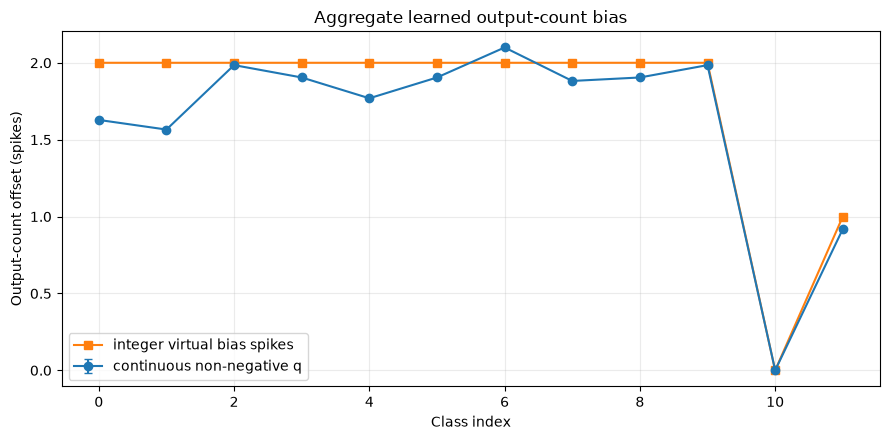

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = bias['class_index']
ax.errorbar(x, bias['lif_count_bias_nonnegative_mean'], yerr=bias['lif_count_bias_nonnegative_std'], marker='o', capsize=3, label='continuous non-negative q')
ax.plot(x, bias['lif_count_bias_integer_mean'], marker='s', label='integer virtual bias spikes')
ax.set_xlabel('Class index')
ax.set_ylabel('Output-count offset (spikes)')
ax.set_title('Aggregate learned output-count bias')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


## Count-bias calibration trajectory

Only the aggregate trajectory across seeds is shown.


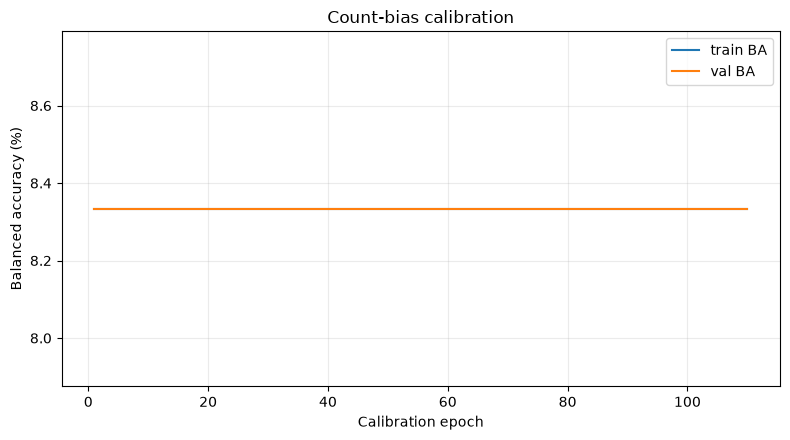

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(history['epoch'], 100 * history['train_ba_mean'], label='train BA')
ax.plot(history['epoch'], 100 * history['val_ba_mean'], label='val BA')
ax.set_xlabel('Calibration epoch')
ax.set_ylabel('Balanced accuracy (%)')
ax.set_title('Count-bias calibration')
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
